# Clean-Slate 🧼
### Momentum crashes hard. What if you run it on the part of the return that *isn't* the market?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Cleaner than total?: Unproven here](https://img.shields.io/badge/Cleaner_than_total%3F-Unproven_here-8b949e?style=flat-square)

[Study 24](../../24-stampede/) left momentum bruised: the famous premium has gone faint on the modern S&P 500, and it still carries a catastrophic crash. This study asks whether a clever tweak fixes the worst of it. **Residual momentum** (Blitz, Huij & Martens 2011): instead of ranking stocks by their *total* return, first strip out the part explained by the market — the systematic, beta-driven bit — and rank on the **residual**, the idiosyncratic leftover. The thesis: the tradable momentum lives in the residual, while the *crash* lives in the systematic exposure you just removed.

This is the desk's eighth idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §3.7). We prove the engine on a synthetic panel where momentum is baked into the residual (and a null), then run it on the real S&P 500 — where the premium stays faint, the "cleaner cousin" claim **fails a paired test**, and what reliably collapses the crash is stacking vol-management on top.

> 📓 **Plain-language layer.** The residualisation, the HAC alpha, the null-seed battery and the paired bootstrap are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** panel, so the real-S&P numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from clean_slate import data, momentum, strategy, decompose, extension

# Offline synthetic panel: a MOMENTUM tape (persistent idiosyncratic drift -> the *residual* carries the
# momentum) and a no-momentum NULL. The real S&P 500 verdict is in ../docs/results.md.
panel,  market,  truth = data.synthetic_panel(mom_strength=0.0016, seed=25)   # the momentum tape
panel0, market0, _     = data.synthetic_panel(mom_strength=0.0,    seed=25)   # the null
print(f"{truth.n_stocks} stocks x {truth.n_bars} days | baked mom_strength={truth.mom_strength} | null=0")


150 stocks x 4032 days | baked mom_strength=0.0016 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is residual momentum real? | 🟡 **A higher point estimate than total** — residual-WML alpha **+5.0%/yr** (*t* **+1.0**) vs total's +4.4% (*t* +0.9) — but both are indistinguishable from zero on the modern S&P 500. |
| Is it *cleaner* than total momentum? | ⚪ **Unproven here** — "cleaner" is a claim about a *difference*, so the gaps get a paired block-bootstrap: skew gap **-0.19** (95% CI **[-0.88, +0.44]**), Sharpe gap **-0.12** (95% CI **[-0.28, +0.02]**). Neither clears zero, and both lean the *wrong* way. |
| What actually tames the crash? | ✅ **The stack** — residualise *and* vol-manage and the drawdown collapses to **-30%** at a Sharpe of **+0.16**. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Cleaner than total momentum? `UNPROVEN HERE`** — the crash is the engineerable part; the "cleaner cousin" billing doesn't survive a paired test on this tape.

## 1 · The claim 📣

Decompose each stock's return into a market part and an idiosyncratic residual: $r_i = \beta_i\,r_{\text{mkt}} + \varepsilon_i$. Rank on the 12-1 momentum of the **residual** $\varepsilon_i$, not the total $r_i$. Here's the residual-momentum decile profile on our synthetic tape — residual winners out-earn residual losers:

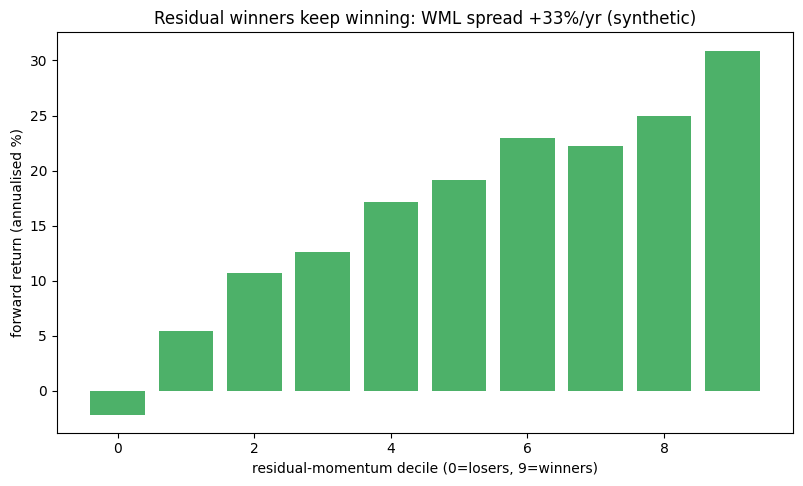

In [2]:
sp = momentum.momentum_spread(panel, market, residual=True)
d = sp['decile_fwd_ann']
fig, ax = plt.subplots(); ax.bar(d.index, d.values, color='#2ea44f', alpha=.85)
ax.set_xlabel('residual-momentum decile (0=losers, 9=winners)'); ax.set_ylabel('forward return (annualised %)')
ax.set_title(f"Residual winners keep winning: WML spread {sp['wml_ann_pct']:+.0f}%/yr (synthetic)")
plt.show()

## 2 · So what? 💰

If the momentum premium survives residualisation but the crash doesn't, you get the prize [Study 24](../../24-stampede/) couldn't bank: momentum's return without momentum's gut-wrenching tail. That's why residual (and its cousin, industry-neutral) momentum is what serious factor shops actually run. The desk's question is always the same: how much of the improvement is real on the sample you'd trade, and how much needs more than we've got?

## 3 · How we'd know 🔬

Three checks:

1. **Is the residual premium real?** The residual-WML alpha, with a *t*-stat — and a **null battery** (no persistence ⇒ no premium, checked across seeds, because one tape is one draw).
2. **Is it cleaner than total momentum?** Not by eyeballing two point estimates — "cleaner" is a claim about a *difference*, so the skew and Sharpe gaps get a **paired block-bootstrap** on the books' common window.
3. **Can the tail be tamed further?** Stack residualisation with vol-management.

**Confirmed line:** the residual premium is significant *and* the paired gaps clear zero — anything less is directional, not proven.

## 4 · The teardown 🔧

### 4a · Residual momentum vs the null
Run the residual-WML factor on both synthetic panels.

In [3]:
for label, (p, mk) in [('momentum', (panel, market)), ('null', (panel0, market0))]:
    cmp = strategy.compare(p, mk, cost_bps=5.0); a = decompose.capm_alpha(p, mk, cost_bps=5.0)
    print(f"{label:9s}: residual Sharpe {cmp['residual']['sharpe']:+.2f} (total {cmp['total']['sharpe']:+.2f}), "
          f"alpha {a['alpha_ann_pct']:+.1f}%/yr (HAC t {a['alpha_t']:+.1f})")

momentum : residual Sharpe +4.43 (total +4.00), alpha +32.2%/yr (HAC t +15.8)


null     : residual Sharpe -0.53 (total +0.02), alpha -4.2%/yr (HAC t -2.1)


The momentum tape lights up (alpha HAC *t* ≈ 16) — the machine works. The null tape reads a *negative* alpha (≈ −4%/yr, *t* ≈ −2): alarming until you remember a single 16-year no-momentum tape is **one draw** plus a cost drag. The quants notebook runs a five-seed null battery and shows the spread is centred on ≈ 0 — this seed is just a tail draw.

### 4b · On the real market — the paired test ⚖️
On the current S&P 500 (quoted from [`../docs/results.md`](../docs/results.md)):

- Residual-WML alpha **+5.0%/yr** (*t* **+1.0**) vs total momentum's +4.4% (*t* +0.9) — a higher point estimate, but **both are noise-level**, and comparing two insignificant point estimates proves nothing.
- Head-to-head on the same months the residual book is *not* better behaved: monthly skew **-0.23** vs total's **-0.04**, drawdown **-70%** vs **-67%**, standalone Sharpe **-0.01**, turnover **12×/yr**.
- The **paired block-bootstrap** of the differences settles it: skew gap **-0.19** (95% CI **[-0.88, +0.44]**), Sharpe gap **-0.12** (95% CI **[-0.28, +0.02]**) — neither clears zero, and both lean the *wrong* way.

Here is the same paired test on our synthetic tape, where the momentum *is* baked into the residual — so the residual book must win, and the test must see it:

In [4]:
pb = decompose.paired_crash_bootstrap(panel, market, n_boot=2000, seed=0, cost_bps=5.0)
print(f"paired gaps (residual - total) on {pb['n_months']} synthetic months:")
print(f"  Sharpe gap {pb['sharpe_diff']:+.2f}  95% CI [{pb['sharpe_ci_low']:+.2f}, {pb['sharpe_ci_high']:+.2f}]"
      f"  -> {'clears zero' if pb['sharpe_significant'] else 'straddles zero'}")
print(f"  skew   gap {pb['skew_diff']:+.2f}  95% CI [{pb['skew_ci_low']:+.2f}, {pb['skew_ci_high']:+.2f}]"
      f"  -> {'clears zero' if pb['skew_significant'] else 'straddles zero'}")
print('On the REAL S&P 500: skew gap -0.19 [-0.88, +0.44], Sharpe gap -0.12 [-0.28, +0.02] -- nothing clears zero.')

paired gaps (residual - total) on 163 synthetic months:
  Sharpe gap +0.51  95% CI [+0.04, +0.92]  -> clears zero
  skew   gap +0.18  95% CI [-0.14, +0.52]  -> straddles zero
On the REAL S&P 500: skew gap -0.19 [-0.88, +0.44], Sharpe gap -0.12 [-0.28, +0.02] -- nothing clears zero.


### 4c · The real fix — stack the defences
Residualise *and* vol-manage. On the real S&P 500 the drawdown collapses:

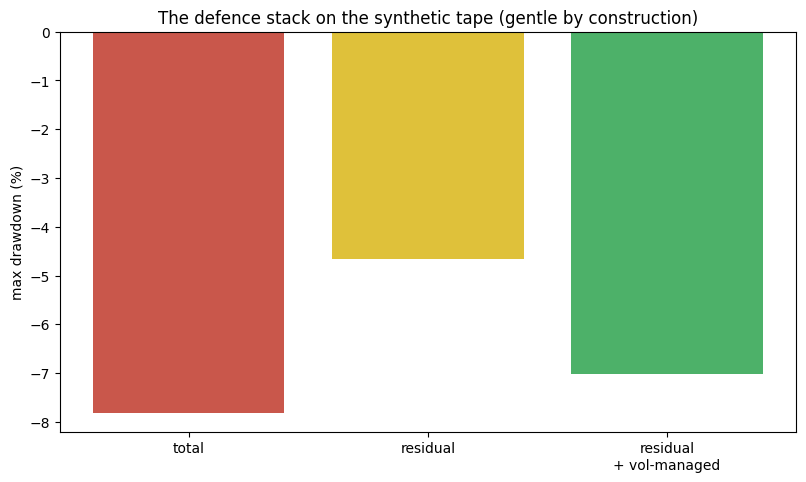

On the REAL S&P 500: drawdown -67% (total) -> -70% (residual alone) -> -30% (stacked).


In [5]:
st = extension.defence_stack(panel, market, cost_bps=5.0)
labels = ['total', 'residual', 'residual\n+ vol-managed']
dds = [st['total']['max_drawdown_pct'], st['residual']['max_drawdown_pct'], st['residual_vol_managed']['max_drawdown_pct']]
fig, ax = plt.subplots(); ax.bar(labels, dds, color=['#c0392b','#dab617','#2ea44f'], alpha=.85)
ax.set_ylabel('max drawdown (%)'); ax.set_title('The defence stack on the synthetic tape (gentle by construction)')
plt.show()
print('On the REAL S&P 500: drawdown -67% (total) -> -70% (residual alone) -> -30% (stacked).')

The synthetic tape has only a mild, beta-driven tail, so there is little crash to engineer away there. The stack's value shows on the **real** tape: residualising *alone* does not dent the drawdown (**-70%** vs total **-67%**), but residualise *and* vol-manage and it collapses to **-30%** at a Sharpe of **+0.16** — though that is the overlay's engineering as much as the residual's.

## 5 · The verdict 🧾

- **Higher point estimate, still faint** — residual alpha +5.0%/yr (*t* +1.0); both books are noise-level.
- **"Cleaner" is unproven** — the paired gaps (skew -0.19, Sharpe -0.12) straddle zero and lean the wrong way.
- **The stack works** — residual + vol-managed cuts the drawdown to -30% at a Sharpe of +0.16.

> **Signal `WEAK` · Tradability `FRAGILE` · Cleaner than total momentum? `UNPROVEN HERE`.** The crash is the engineerable part; the cleaner-cousin billing didn't survive the paired test.

## 6 · Could you trade it? 💸

- **The standalone book earns nothing** (Sharpe -0.01) and you must short losers at **12×/yr** turnover.
- **But the ride is improvable.** Residual momentum is a clean *platform* for crash management; stacked with vol-targeting the drawdown drops to **-30%**.
- **Costs bite** (fast turnover), and the 1-factor residual leaves value-driven crash risk on the table — full FF3 residuals would help.

> Tradability **`FRAGILE`**; "cleaner than total" is **`UNPROVEN HERE`** — the worked complement ([`../docs/extension.md`](../docs/extension.md)) stacks the defences.

## 7 · Going further 🚪

- **The defence stack** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): total → residual → residual + vol-managed — the tail only yields once both defences stack.
- **Full Fama-French residuals.** A 1-factor (market) residual misses the *value* rebound that drives momentum crashes; FF3 (MKT, SMB, HML) residuals — the source's recipe — should shed more of the tail. Rerun the paired test on them.
- **Industry-neutral momentum.** Another route to the same end (strip sector bets); does it beat residualisation?

PRs welcome — add the FF3 residual, or find which neutralisation best tames the crash.